In [336]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

fname = "20260724_kcf_export_anonymized.xlsx"
candidates = ["/Users/gracegibson/work/green_wave/greenwave/", "/mnt/user-data/uploads/", "./"]
path = next(p for p in candidates if os.path.exists(p + fname))

df = pd.read_excel(path + fname, sheet_name=None)
logs = df["Logs"]
logs["Log Date"] = pd.to_datetime(logs["Log Date"])
print("Number of logs: ", len(logs))
logs = logs.dropna(subset=["Log Date"])
print("Number of logs after drop no date: ", len(logs))

Number of logs:  4692
Number of logs after drop no date:  4691


In [337]:
def get_farm_season_species_log(farm: str, season: str, species: str, log: str):
    farm = logs[logs["Farm Name"] == farm]
    farm_season = farm[farm["Season"] == season]
    farm_season_species = farm_season[farm_season["Species"] == species]
    return farm_season_species[farm_season_species["Log Type"] == log]


### Goal: Baseline Growth Model
2 possible targets: 
- Target 1: Density/yield of kelp as a function of age (days since outplanting)
- Target 2= Growth rate as a function of a only or mix of date (proxy for days since outplanting, water temperature), current yield, and past yield

In [338]:
# 2 event types for baseline:
# outplanting = seeding event (give us day 0 + line length)
# samples = density measurement (lbs/ft) on a date
outplant = logs[logs["Log Type"] == "outplanting"]
samples = logs[logs["Log Type"] == "sample"]

# one farm crop of one species in one season
GROUP = ["Farm Name", "Season", "Species"] 

# how many groups have multiple outplanting dates
n_outplants = outplant.groupby(GROUP)["Log Date"].nunique().rename("n_dates_outplanting").reset_index()
print("Number of groups with 1 outplanting date: ", len(n_outplants[n_outplants["n_dates_outplanting"] == 1]))
print("Number of groups with >1 outplanting date: ", len(n_outplants[n_outplants["n_dates_outplanting"] > 1]))

# what's a typical range for farms with multiple outplanting dates
range_outplants = outplant.groupby(GROUP)["Log Date"].agg(lambda x: (x.max()-x.min()).days).rename("outplant_range").reset_index()
avg = range_outplants[range_outplants["outplant_range"] > 0]["outplant_range"].median()
print("Check number of groups with 1 outplanting date: ", len(range_outplants[range_outplants["outplant_range"] == 0]))
print("Median outplanting range for farms with multiple outplanting dates:", avg)


Number of groups with 1 outplanting date:  185
Number of groups with >1 outplanting date:  95
Check number of groups with 1 outplanting date:  185
Median outplanting range for farms with multiple outplanting dates: 21.0


In [339]:
# add harvests
harvest = logs[logs["Log Type"] == "harvest"].copy()
harvest["lbs_ft"] = harvest["Weight"] / harvest["Line Length"]
harvest[harvest["lbs_ft"] == harvest["lbs_ft"].max()]
# remove outliers -- future 
lo, hi = harvest["lbs_ft"].quantile([0.02, 0.98])           # remove outlier rates
harvest = harvest[(harvest["lbs_ft"] >= lo) & (harvest["lbs_ft"] <= hi)]
print("harvest max lbs/ft: ", harvest["lbs_ft"].max(), " sample max lbs/ft: ", samples["Weight"].max())


harvest max lbs/ft:  11.175  sample max lbs/ft:  26.46


,Created Date,Updated Date,Farm Name,City,State,Country,Season,Log Date,Log Type,Species,Line Length,Weight,Temperature,Notes,lbs_ft
1059,2025-07-03 21:33:55,2025-07-03 21:33:55,Farm_59,Ritchie Bay in Clayoquot Sound,BC,CA,Season 24/25,2025-06-10,harvest,bull_kelp,120.0,1341.0,NaN,Harvest of full plants. Kelp was chopped on th...,11.175
1060,2025-07-03 21:33:55,2025-07-03 21:33:55,Farm_59,Ritchie Bay in Clayoquot Sound,BC,CA,Season 24/25,2025-06-10,harvest,bull_kelp,120.0,1341.0,NaN,"full plant (blades, stipes, holdfasts). From o...",11.175


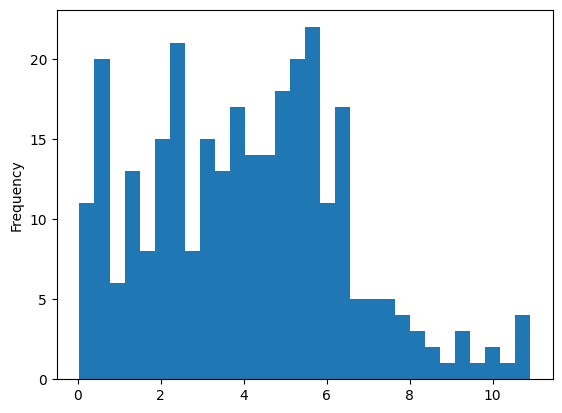

In [340]:
harvest[harvest["Log Date"].dt.month == 5]['lbs_ft'].plot.hist(bins=30)
harvest[harvest['lbs_ft'] == harvest['lbs_ft'].max()]

<Axes: ylabel='Frequency'>

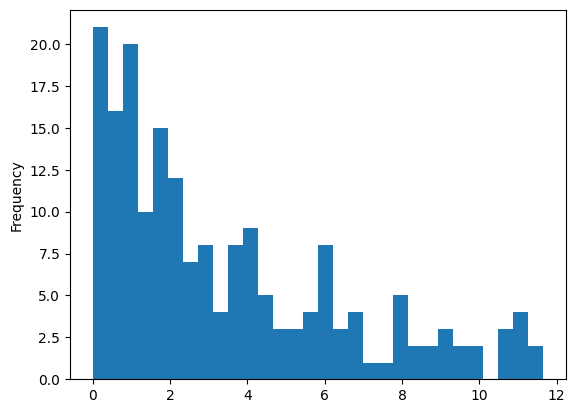

In [341]:
lo, hi = samples["Weight"].quantile([0.02, 0.98])           # remove outlier rates
samples = samples[(samples["Weight"] >= lo) & (samples["Weight"] <= hi)]
samples[samples["Log Date"].dt.month == 5]['Weight'].plot.hist(bins=30)

In [342]:
samples[samples["Weight"] == samples["Weight"].max()]

,Created Date,Updated Date,Farm Name,City,State,Country,Season,Log Date,Log Type,Species,Line Length,Weight,Temperature,Notes
3130,2024-05-08 15:55:04,2024-05-08 15:55:04,Farm_19,Homer,AK,US,Season 23/24,2024-05-04,sample,sugar_kelp,NaN,11.66,NaN,NaN


In [343]:
# find the earliest seed date per group
day_zero = outplant.groupby(GROUP)["Log Date"].min().rename("seed_date").reset_index()

# remove groups with multiple outplanting dates
# if one or more outplanting on same day, consider one seeding date
day_zero_only = day_zero.merge(range_outplants[range_outplants["outplant_range"] == 0], on=GROUP, how="inner")
print("Number of groups with 1 outplanting date: ", len(day_zero_only))

# attach seed_date to each sample to compute age
# age = number of days the kelp had been growing when sampling
data = samples.merge(day_zero_only, on=GROUP, how="inner")
data.head()

Number of groups with 1 outplanting date:  185


,Created Date,Updated Date,Farm Name,City,State,Country,Season,Log Date,Log Type,Species,Line Length,Weight,Temperature,Notes,seed_date,outplant_range
0,2026-07-04 22:27:19,2026-07-04 22:27:19,Farm_27,,NL,CA,Season 25/26,2026-07-03,sample,sugar_kelp,NaN,1.90,NaN,At wastewater site. \nWhales and dolphins nearby,2026-01-07,0
1,2026-07-04 22:25:32,2026-07-04 22:25:32,Farm_27,,NL,CA,Season 25/26,2026-07-03,sample,sugar_kelp,NaN,1.34,NaN,Wastewater site,2026-01-07,0
2,2026-07-04 22:23:53,2026-07-04 22:23:53,Farm_27,,NL,CA,Season 25/26,2026-07-03,sample,sugar_kelp,NaN,2.05,NaN,At the wastewater site.,2026-01-07,0
3,2026-07-02 07:11:56,2026-07-02 07:11:56,Farm_64,juneau,AK,US,Season 25/26,2026-05-15,sample,split_kelp,NaN,2.60,NaN,NaN,2025-11-29,0
4,2026-06-30 12:33:58,2026-06-30 12:33:58,Farm_65,Hampton Bays,NY,US,Season 25/26,2026-05-16,sample,sugar_kelp,NaN,0.61,NaN,Two samples taken first sample 1.16 and second...,2025-12-21,0


In [344]:
# are samples taken on a consistent basis?
# drop samples taken on the same day
# get diff between consequetive samples in days
# group by Farm-Season-Species and take mean and variance

# remove instances where outplanting dates are far apart 
sorted_samples = (
    samples
    .assign(**{"Log Date": pd.to_datetime(samples["Log Date"])})
    .drop_duplicates(subset = ["Farm Name", "Season", "Species", "Log Date"])
    .sort_values(["Farm Name", "Season", "Species", "Log Date"])
    # .agg(avg_days_btw_samples="mean", var_days_btw_samples="var")
)
sorted_samples["days_gap"] = sorted_samples.groupby(GROUP)["Log Date"].diff().dt.days
avg_gap = (
    sorted_samples
    .groupby(GROUP)["days_gap"]
    .agg(num_sample_days="count", avg_days_btw_samples="mean", std_days_btw_samples="std")
    .reset_index()
)
avg_gap["num_sample_days"] = avg_gap["num_sample_days"] +1
print("avg/median number of days between samples: ", sorted_samples["days_gap"].dropna().mean(), sorted_samples["days_gap"].dropna().median())
print("std number of days between samples: ", sorted_samples["days_gap"].dropna().std())
print("avg/median of sample days taken per season: ", avg_gap["num_sample_days"].dropna().mean(), avg_gap["num_sample_days"].dropna().median())
print("", avg_gap["avg_days_btw_samples"].dropna().mean())
print("", avg_gap["std_days_btw_samples"].dropna().mean())

avg/median number of days between samples:  24.029411764705884 21.0
std number of days between samples:  15.328540131503148
avg/median of sample days taken per season:  3.365217391304348 3.0
 27.981207028265853
 10.791092877577265


In [345]:
avg_gap

,Farm Name,Season,Species,num_sample_days,avg_days_btw_samples,std_days_btw_samples
0,Farm_1,Season 22/23,alaria,3,38.000000,4.242641
1,Farm_1,Season 22/23,sugar_kelp,4,32.000000,10.816654
2,Farm_1,Season 23/24,bull_kelp,1,NaN,NaN
3,Farm_1,Season 23/24,sugar_kelp,4,15.666667,9.814955
4,Farm_1,Season 24/25,sugar_kelp,2,20.000000,NaN
...,...,...,...,...,...,...
225,Farm_83,Season 25/26,alaria,3,42.500000,2.121320
226,Farm_83,Season 25/26,skinny_kelp,3,37.500000,4.949747
227,Farm_83,Season 25/26,sugar_kelp,3,42.500000,2.121320
228,Farm_9,Season 23/24,sugar_kelp,3,18.500000,7.778175


In [346]:
get_farm_season_species_log("Farm_1", "Season 22/23", "sugar_kelp", "sample").sort_values("Log Date")

,Created Date,Updated Date,Farm Name,City,State,Country,Season,Log Date,Log Type,Species,Line Length,Weight,Temperature,Notes
4471,2023-06-21 18:52:23,2023-10-11 22:45:33,Farm_1,Kodiak,AK,US,Season 22/23,2023-03-05,sample,sugar_kelp,NaN,0.13,NaN,NaN
4472,2023-06-21 18:52:22,2023-10-11 22:45:33,Farm_1,Kodiak,AK,US,Season 22/23,2023-03-05,sample,sugar_kelp,NaN,0.21,NaN,NaN
4473,2023-06-21 18:52:22,2023-10-11 22:45:33,Farm_1,Kodiak,AK,US,Season 22/23,2023-03-05,sample,sugar_kelp,NaN,0.05,NaN,NaN
4456,2023-06-21 18:55:25,2023-10-11 22:45:33,Farm_1,Kodiak,AK,US,Season 22/23,2023-03-25,sample,sugar_kelp,NaN,1.80,NaN,NaN
4457,2023-06-21 18:55:25,2023-10-11 22:45:33,Farm_1,Kodiak,AK,US,Season 22/23,2023-03-25,sample,sugar_kelp,NaN,1.70,NaN,NaN
4458,2023-06-21 18:55:25,2023-10-11 22:45:33,Farm_1,Kodiak,AK,US,Season 22/23,2023-03-25,sample,sugar_kelp,NaN,1.90,NaN,NaN
4440,2023-06-21 18:58:06,2023-10-11 22:45:33,Farm_1,Kodiak,AK,US,Season 22/23,2023-04-29,sample,sugar_kelp,NaN,3.00,NaN,NaN
4441,2023-06-21 18:58:06,2023-10-11 22:45:33,Farm_1,Kodiak,AK,US,Season 22/23,2023-04-29,sample,sugar_kelp,NaN,3.20,NaN,NaN
4442,2023-06-21 18:58:06,2023-10-11 22:45:33,Farm_1,Kodiak,AK,US,Season 22/23,2023-04-29,sample,sugar_kelp,NaN,2.90,NaN,NaN
4423,2023-06-21 18:59:26,2023-10-11 22:45:33,Farm_1,Kodiak,AK,US,Season 22/23,2023-06-09,sample,sugar_kelp,NaN,10.20,NaN,NaN


(ft * today *wr + pred_today*wp)/(wr +wp)

jim skill - try it out 
time series modeling 
same mean bettween sample yield and true yield different variance maybe
expected growth between days
expected true yield distribution - take average 
several distributions based on date/weather and can plot new ones for each month/week, etc break in time
true observation with prior versus expectation
project based on time of year 
combine variance on original and variance on growth 
informed prior and new data
expected mean - a little smaller if true bigger than the expected prior 
and then go along from each true sample make a distribution and use that as the prior to the next true sample and adjust the distribution based off that

bayesian foundational 
best fit ? so few data points 
outplanting sample = 0, no variance - certain type of variable

fitting all these variances - avoid, focus on the means
sample differential - samples from same line or multiple lines
linear model (obviously not flat, added the bottom)- y2-y1/d2-d1 as a function of y1 + d1+d2/2 - focus linearity on lots of thing, but month apart if consistent then fine but confirm. -> curve, start at 0 and project from this curve. 2nd term can be a polynomial or whatever fitting that smoothly binning by month, GAM- generalized additive model. both terms have smooth relationship but not necessarily mono-directional
max forfeit across all data 

Ask Jim at some point - figure out exactly what you're looking for for this certain type of problem 
observe all that error on that initial line - what percentage is measurement error versus model error 
10 data pts on same day - could be measurement error if non-biased 
growth rate versus model/error distribution known 
expected curve 
snap up and down based on each sample and knowing how much to snap up and down is the key thing 
measurement error is 0 snap all the way to new sample, model error is 0 then continue to follow the line and continue all the way ignore the "error" with the new sample 
fit model and create the curve just from one starting 0 date meaning 
pick an outplanting date how's what you expect it to look like
figure out shape of these terms - smooth out curve, probably need to remove outliers, 
like how much do we trust this curve based on the error - can we somehow approximate those. Jim may have more answers 

slack David on slack about meeting to discuss where I'm at with GreenWave work 


---
# Modeling: from notes → code

The plan from the working-session notes, implemented in four steps:

1. **Look at the raw data** — yield vs. age, all farm-seasons overlaid.
2. **Split the error** — same-day replicate samples tell us how much of the scatter is *measurement* error vs. *model* error. This is what sets how far we "snap" toward each new sample.
3. **GAM (simple → growth-rate form)** —
   - GAM 1: yield ~ s(age). The simplest expected curve.
   - GAM 2: growth rate (y₂−y₁)/(d₂−d₁) ~ s(current yield) + s(day of season), then integrate forward from 0 at the outplanting date. This is the "linear model, y2-y1/d2-d1 as a function of y1 + (d1+d2)/2 → GAM" idea from the notes, and it respects the known-zero anchor at outplanting.
4. **Bayesian sequential updating** — treat the projected curve as the prior; each new sample pulls the estimate partway toward it via a Kalman-style update. The weight is exactly `(ft*wr + pred*wp)/(wr+wp)` with weights = 1/variance.

## 0. Raw data: yield vs. age

In [347]:
# re-attach outplanting date as a 0 weight/yield sample only for farm-seasons
# with one outplanting date. The observed growth rate could look like declining growth when
# multiple outplanting dates between samples or no growth when different lines planted
day_zero_only["Weight"] = 0
samples = samples.dropna(subset=["Weight"])[['Farm Name', 'Season', 'Species', 'Log Date', 'Weight']]

# NOTE: rename() returns a copy -- chaining .drop(inplace=True) onto it modified the copy and
# discarded it, so day_zero_only was never actually renamed. Assign the result instead:
day_zero = (day_zero_only
            .rename(columns={"seed_date": "Log Date"})
            .drop(columns=["outplant_range"]))
day_zero["is_outplant"] = True                       # flag so we can identify zero-anchored pairs later

harvest["is_harvest"] = True
harvest = harvest.dropna(subset=["lbs_ft"])[['Farm Name', 'Season', 'Species', 'Log Date', 'lbs_ft', 'is_harvest']]
harvest.head()

,Farm Name,Season,Species,Log Date,lbs_ft,is_harvest
1,Farm_1,Season 25/26,sugar_kelp,2026-04-27,0.781250,True
5,Farm_61,Season 25/26,alaria,2026-05-09,9.473333,True
6,Farm_37,Season 25/26,sugar_kelp,2026-06-17,2.750000,True
7,Farm_37,Season 25/26,sugar_kelp,2026-06-07,2.540000,True
8,Farm_37,Season 25/26,sugar_kelp,2026-06-05,2.510000,True


In [348]:
samples.rename(columns={"Weight": "lbs_ft"}, inplace=True)
day_zero.rename(columns={"Weight": "lbs_ft"}, inplace=True)
data = pd.concat([harvest.assign(is_outplant=False), day_zero.assign(is_harvest=False), samples.assign(is_outplant=False, is_harvest=False)])
data = data.sort_values(['Farm Name', 'Season', 'Species', 'Log Date']).reset_index(drop=True)
data.head()

,Farm Name,Season,Species,Log Date,lbs_ft,is_harvest,is_outplant
0,Farm_1,Season 22/23,alaria,2022-11-18,0.00,False,True
1,Farm_1,Season 22/23,alaria,2023-03-25,0.48,False,False
2,Farm_1,Season 22/23,alaria,2023-03-25,0.32,False,False
3,Farm_1,Season 22/23,alaria,2023-04-29,1.20,False,False
4,Farm_1,Season 22/23,alaria,2023-04-29,0.90,False,False


In [349]:
print(data['Species'].unique())
sugar_kelp_data = data[data["Species"] == "sugar_kelp"]

['alaria' 'sugar_kelp' 'bull_kelp' 'skinny_kelp' 'other_species'
 'dragon_kelp' 'giant_kelp' 'split_kelp' 'three_rib_kelp']


In [350]:
sugar_kelp_data.columns

Index(['Farm Name', 'Season', 'Species', 'Log Date', 'lbs_ft', 'is_harvest',
       'is_outplant'],
      dtype='object')

In [351]:
sugar_kelp_data["is_harvest"].value_counts()

is_harvest
False    1154
True      368
Name: count, dtype: int64

In [354]:
sugar_kelp_data_samp = sugar_kelp_data[~sugar_kelp_data["is_outplant"]]
# get average of same-day replicate samples/harvests
# average same-day replicate samples first: multiple samples on one date are measurements of the
# same true yield, and without this step consecutive same-day rows give d2 - d1 = 0 (rate = inf)
print("n samples/harvests before same-day averaging: ", len(sugar_kelp_data_samp))
data_samp_day_avg = (sugar_kelp_data_samp
    .groupby(GROUP + ["Log Date"], as_index=False)
    .agg(lbs_ft=("lbs_ft", "mean"), n_samples=("lbs_ft", "count"), is_harvest=("is_harvest", "max")))
print("n samples/harvests after same-day averaging: ", len(data_samp_day_avg))
print("Rows with harvest and sample on same day:")
data_samp_day_avg[data_samp_day_avg["is_harvest"] & data_samp_day_avg["n_samples"] > 1]
# add back is_harvest and is_outplant


n samples/harvests before same-day averaging:  1416
n samples/harvests after same-day averaging:  822
Rows with harvest and sample on same day:


,Farm Name,Season,Species,Log Date,lbs_ft,n_samples,is_harvest


In [359]:
len(sugar_kelp_data[sugar_kelp_data["is_outplant"]])

106

In [360]:
len(sugar_kelp_data.groupby(GROUP))

161

In [ ]:
# add an outplanting date to samples/harvests to remove samples taken prior to outplanting
seed_dates = (sugar_kelp_data.loc[sugar_kelp_data["is_outplant"], GROUP + ["Log Date"]]
              .rename(columns={"Log Date": "seed_date"}))
seed_dates["seed_date"].dt.month.value_counts(dropna=False)
#TODO: why is there outplanting in March, April, and July - will want to investigate and remove

seed_date
11    52
12    27
10    12
1      8
3      4
7      1
2      1
4      1
Name: count, dtype: int64

In [365]:

# keep only groups that have a day-0 anchor (single-outplant-date groups), and drop any
# samples logged before their outplanting date
sugar_kelp_data_samp = sugar_kelp_data_samp.merge(seed_dates, on=GROUP, how="inner")
sugar_kelp_data_op = sugar_kelp_data[sugar_kelp_data["is_outplant"]]
sugar_kelp_data_op["seed_date"] = sugar_kelp_data_op["Log Date"]
sugar_kelp_data = pd.concat([sugar_kelp_data_samp, sugar_kelp_data_op])
print("n (before remove samples logged before outplanting): ", len(sugar_kelp_data))
sugar_kelp_data = sugar_kelp_data[sugar_kelp_data["Log Date"] > sugar_kelp_data["seed_date"]]
print("n (after remove samples logged before outplanting): ", len(sugar_kelp_data))
sugar_kelp_data = sugar_kelp_data.sort_values(GROUP + ["Log Date"]).reset_index(drop=True)

# turn samples into observed growth rates
# y2-y1 / d2-d1 as a function of y1 + (d1+d2)/2
sugar_kelp_data["y1"] = sugar_kelp_data.groupby(GROUP)["lbs_ft"].shift(1)   # previous yield
sugar_kelp_data["d1"] = sugar_kelp_data.groupby(GROUP)["Log Date"].shift(1) # previous date
sugar_kelp_data["date_diff"] = (sugar_kelp_data["Log Date"] - sugar_kelp_data["d1"]).dt.days
sugar_kelp_data["rate"] = (sugar_kelp_data["lbs_ft"] - sugar_kelp_data["y1"]) / sugar_kelp_data["date_diff"]

# midpoint date: floor-divide the day count so odd gaps stay whole dates (no 12:00 component)
sugar_kelp_data["mid_date"] = sugar_kelp_data["d1"] + pd.to_timedelta(sugar_kelp_data["date_diff"] // 2, unit="D")

sugar_kelp_data.head()

n (before remove samples logged before outplanting):  783
n (after remove samples logged before outplanting):  675


/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_6919/2536844874.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sugar_kelp_data_op["seed_date"] = sugar_kelp_data_op["Log Date"]


,Farm Name,Season,Species,Log Date,lbs_ft,is_harvest,is_outplant,seed_date,y1,d1,date_diff,rate,mid_date
0,Farm_1,Season 22/23,sugar_kelp,2023-03-05,0.13,False,False,2022-11-18,NaN,NaT,NaN,NaN,NaT
1,Farm_1,Season 22/23,sugar_kelp,2023-03-05,0.21,False,False,2022-11-18,0.13,2023-03-05,0.0,inf,2023-03-05
2,Farm_1,Season 22/23,sugar_kelp,2023-03-05,0.05,False,False,2022-11-18,0.21,2023-03-05,0.0,-inf,2023-03-05
3,Farm_1,Season 22/23,sugar_kelp,2023-03-25,1.80,False,False,2022-11-18,0.05,2023-03-05,20.0,0.0875,2023-03-15
4,Farm_1,Season 22/23,sugar_kelp,2023-03-25,1.70,False,False,2022-11-18,1.80,2023-03-25,0.0,-inf,2023-03-25


## GAM: growth rate ~ s(current yield) + s(day of season)

Fit on the rate observations built above. Everything is calendar-date based: the seasonal input is
**day of season** (days since the Oct 1 that started that season), computed from each pair's midpoint
date. The test season is held out of the fit.

In [ ]:
from pygam import LinearGAM, s   # pip install pygam

def day_of_season(ts):
    """Days since the Oct 1 that started this date's growing season.
    Oct-Dec dates count from Oct 1 of the same year; Jan-Sep from Oct 1 of the previous year."""
    oct1 = pd.Timestamp(year=ts.year if ts.month >= 10 else ts.year - 1, month=10, day=1)
    return (ts - oct1).days

# hold out the most recent season for evaluation
test_season = "Season 25/26"
gr = sugar_kelp_data.dropna(subset=["y1", "rate"]).copy()
gr = gr[gr["Season"] != test_season]

# pair windows: 5-90 days for sample->sample pairs (too-close = mostly measurement noise,
# too-far = blurred seasonality); zero-anchored pairs (previous point IS the outplanting)
# get 120 days since the median first sample lands ~80 days after outplanting and these
# pairs are the only early-season signal
is_zero_pair = gr["d1"] == gr["seed_date"]
gr = gr[(gr["date_diff"] >= 5) & (np.where(is_zero_pair, gr["date_diff"] <= 120, gr["date_diff"] <= 90))]
print(f"Zero-anchored pairs kept: {int((gr['d1'] == gr['seed_date']).sum())} of {len(gr)} rate observations")

gr["dos"] = gr["mid_date"].apply(day_of_season)      # midpoint date -> days since Oct 1

lo, hi = gr["rate"].quantile([0.02, 0.98])           # remove outlier rates
grc = gr[(gr["rate"] >= lo) & (gr["rate"] <= hi)]
print(f"Growth-rate observations: {len(gr)} ({len(grc)} after outlier trim)")

# rate = intercept + f1(y1) + f2(dos), each f a penalized smooth
gam_curr_yield_dos = LinearGAM(s(0, n_splines=8) + s(1, n_splines=8)).fit(
    grc[["y1", "dos"]].values,   # X: col 0 = current yield y1, col 1 = day of season
    grc["rate"].values)          # y: growth rate (lbs/ft/day)
gam_curr_dos = LinearGAM(s(0, n_splines=8)).fit(
    grc[["dos"]].values,         # X: col 0 = day of season
    grc["rate"].values)          # y: growth rate (lbs/ft/day)
gam_curr_dos_is_harvest = LinearGAM(s(0, n_splines=8)+s(1, n_splines=8)).fit(
    grc[["dos", "is_harvest"]].values,         # X: col 0 = day of season
    grc["rate"].values)          # y: growth rate (lbs/ft/day)


Zero-anchored pairs kept: 0 of 230 rate observations
Growth-rate observations: 230 (220 after outlier trim)


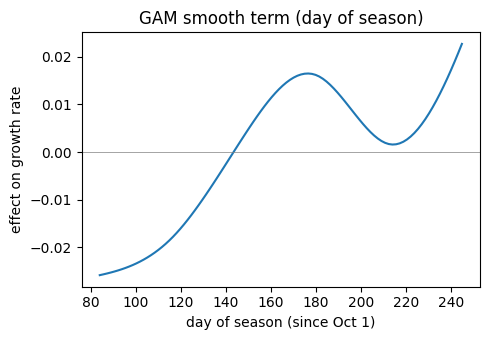

In [367]:
# partial dependence: each smooth term's contribution, the other held fixed
i, name = 0, "day of season (since Oct 1)"
XX = gam_curr_dos.generate_X_grid(term=i)
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(XX[:, i], gam_curr_dos.partial_dependence(term=i, X=XX))
ax.axhline(0, color="gray", lw=0.5)
ax.set_xlabel(name); ax.set_ylabel("effect on growth rate")
ax.set_title("GAM smooth term (day of season)")
plt.tight_layout(); plt.show()


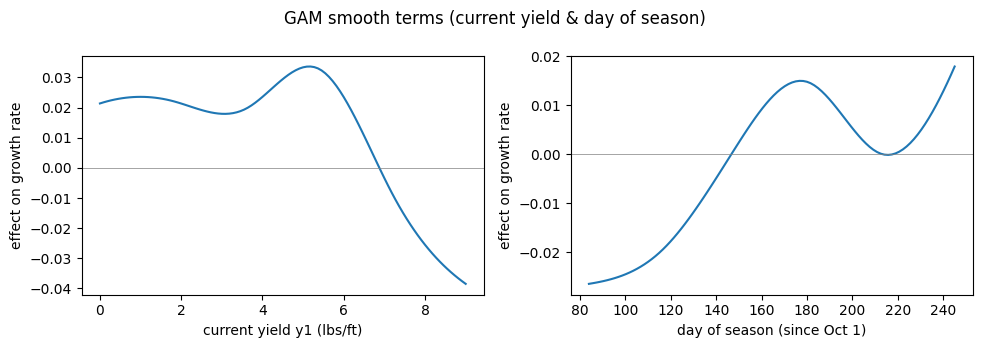

In [ ]:
# partial dependence: each smooth term's contribution, the other held fixed
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for i, (ax, name) in enumerate(zip(axes, ["current yield y1 (lbs/ft)", "day of season (since Oct 1)"])):
    XX = gam_curr_yield_dos.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam_curr_yield_dos.partial_dependence(term=i, X=XX))
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_xlabel(name); ax.set_ylabel("effect on growth rate")
plt.suptitle("GAM smooth terms (current yield & day of season)"); plt.tight_layout(); plt.show()

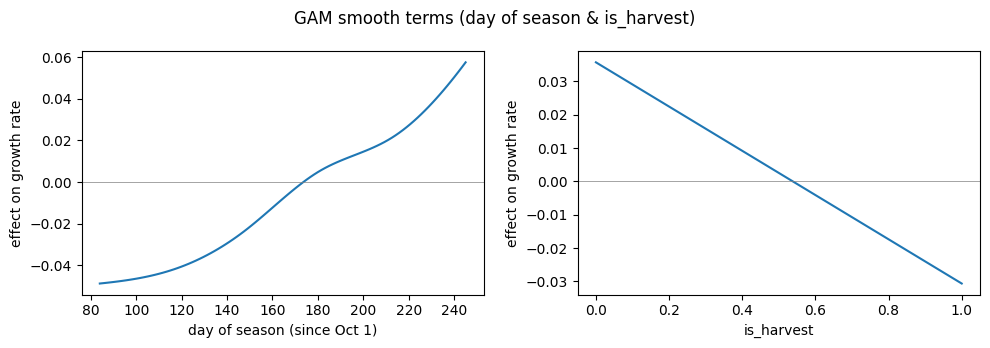

In [370]:
# partial dependence: each smooth term's contribution, the other held fixed
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for i, (ax, name) in enumerate(zip(axes, ["day of season (since Oct 1)", "is_harvest"])):
    XX = gam_curr_dos_is_harvest.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam_curr_dos_is_harvest.partial_dependence(term=i, X=XX))
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_xlabel(name); ax.set_ylabel("effect on growth rate")
plt.suptitle("GAM smooth terms (day of season & is_harvest)"); plt.tight_layout(); plt.show()

In [ ]:
def project_curve_curr_yield_dos(seed_date, horizon_days=220):
    """Expected yield by calendar date, starting from 0 on the outplanting date."""
    seed_date = pd.Timestamp(seed_date)
    dates = pd.date_range(seed_date, periods=horizon_days, freq="D")   # every day of the season
    y, yields = 0.0, [0.0]                                             # the known anchor: yield 0 on seed date
    for dt_ in dates[1:]:                                              # walk forward one day at a time
        rate = gam_curr_yield_dos.predict(np.array([[y, day_of_season(dt_)]]))[0]     # "at this yield, on this date, how fast?"
        y = max(0.0, y + rate)                                         # take one day's step; never below zero
        yields.append(y)
    return pd.Series(yields, index=dates)    

def project_curve_curr_dos(seed_date, horizon_days=220):
    """Expected yield by calendar date, starting from 0 on the outplanting date."""
    seed_date = pd.Timestamp(seed_date)
    dates = pd.date_range(seed_date, periods=horizon_days, freq="D")   # every day of the season
    y, yields = 0.0, [0.0]                                             # the known anchor: yield 0 on seed date
    for dt_ in dates[1:]:                                              # walk forward one day at a time
        rate = gam_curr_dos.predict(np.array([[day_of_season(dt_)]]))[0]     # "at this yield, on this date, how fast?"
        y = max(0.0, y + rate)                                         # take one day's step; never below zero
        yields.append(y)
    return pd.Series(yields, index=dates)  

In [ ]:
# ---- evaluate on the held-out season ----
test = sugar_kelp_data[sugar_kelp_data["Season"] == test_season].copy()

# (a) RATE SPACE: same pair windows as training, then predict rates
tr = test.dropna(subset=["y1", "rate"]).copy()
zp = tr["d1"] == tr["seed_date"]
tr = tr[(tr["date_diff"] >= 5) & (np.where(zp, tr["date_diff"] <= 120, tr["date_diff"] <= 90))]
tr["dos"] = tr["mid_date"].apply(day_of_season)
tr["rate_pred"] = gam_curr_yield_dos.predict(tr[["y1", "dos"]].values)
mae_rate = (tr["rate_pred"] - tr["rate"]).abs().mean()
mae_naive = (grc["rate"].mean() - tr["rate"]).abs().mean()   # baseline: constant mean rate
print(f"rate MAE: GAM {mae_rate:.4f} vs constant-rate baseline {mae_naive:.4f}  (n={len(tr)})")

# (b) YIELD SPACE: project each farm's curve from its outplanting date, compare at sample dates
rows = []
for (farm, season, spec), g in test.groupby(GROUP):
    curve = project_curve_curr_yield_dos(g["seed_date"].iloc[0])
    g = g[g["lbs_ft"] > 0]                       # skip the day-0 anchor itself
    dates = g["Log Date"].clip(upper=curve.index.max())
    rows.append(pd.DataFrame({"obs": g["lbs_ft"].values,
                              "pred": curve.reindex(dates, method="nearest").values}))
ev = pd.concat(rows)
print(f"yield MAE: {(ev['pred']-ev['obs']).abs().mean():.2f} lbs/ft  (n={len(ev)}, "
      f"mean observed {ev['obs'].mean():.2f})")

rate MAE: GAM 0.0627 vs constant-rate baseline 0.0651  (n=57)
yield MAE: 1.53 lbs/ft  (n=71, mean observed 1.93)


In [ ]:
# ---- evaluate on the held-out season ----
test = sugar_kelp_data[sugar_kelp_data["Season"] == test_season].copy()

# (a) RATE SPACE: same pair windows as training, then predict rates
tr = test.dropna(subset=["y1", "rate"]).copy()
zp = tr["d1"] == tr["seed_date"]
tr = tr[(tr["date_diff"] >= 5) & (np.where(zp, tr["date_diff"] <= 120, tr["date_diff"] <= 90))]
tr["dos"] = tr["mid_date"].apply(day_of_season)
tr["rate_pred"] = gam_curr_dos.predict(tr[["dos"]].values)
mae_rate = (tr["rate_pred"] - tr["rate"]).abs().mean()
mae_naive = (grc["rate"].mean() - tr["rate"]).abs().mean()   # baseline: constant mean rate
print(f"rate MAE: GAM {mae_rate:.4f} vs constant-rate baseline {mae_naive:.4f}  (n={len(tr)})")

# (b) YIELD SPACE: project each farm's curve from its outplanting date, compare at sample dates
rows = []
for (farm, season, spec), g in test.groupby(GROUP):
    curve = project_curve_curr_dos(g["seed_date"].iloc[0])
    g = g[g["lbs_ft"] > 0]                       # skip the day-0 anchor itself
    dates = g["Log Date"].clip(upper=curve.index.max())
    rows.append(pd.DataFrame({"obs": g["lbs_ft"].values,
                              "pred": curve.reindex(dates, method="nearest").values}))
ev = pd.concat(rows)
print(f"yield MAE: {(ev['pred']-ev['obs']).abs().mean():.2f} lbs/ft  (n={len(ev)}, "
      f"mean observed {ev['obs'].mean():.2f})")

rate MAE: GAM 0.0622 vs constant-rate baseline 0.0651  (n=57)
yield MAE: 1.36 lbs/ft  (n=71, mean observed 1.93)


In [ ]:
def plot_farm_season(farm, season, species="sugar_kelp", show_harvest=True, ax=None):
    """Plot one farm-season: GAM expected curve + sample dots, optionally harvest yield.

    Parameters
    ----------
    farm : str            e.g. "Farm_12"
    season : str          e.g. "Season 25/26"
    species : str         only sugar_kelp has a fitted GAM for now
    show_harvest : bool   True -> add harvest-implied lbs/ft as diamonds
    ax : matplotlib axis  draw into an existing axis (for grids); None -> new figure
    """
    k = logs[(logs["Species"] == species) &
             (logs["Season"] == season) &
             (logs["Farm Name"] == farm)]

    # outplanting anchor: this function requires a single-outplant-date group
    seed = k.loc[k["Log Type"] == "outplanting", "Log Date"]
    
    if seed.nunique() == 0:
        raise ValueError(f"{farm} / {season}: {seed.nunique()} outplanting dates "
                         "Cannot anchor growth curve")
    if seed.nunique() != 1:
        print(f"{farm} / {season}: {seed.nunique()} outplanting dates "
                         "(curve will use the first one)")
    seed_date = seed.iloc[0]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4.5))

    # GAM prior curve from the outplanting date
    curve = project_curve_curr_dos(seed_date)
    ax.plot(curve.index, curve.values, color="#2a78d6", lw=2, label="GAM expected curve")

    # samples
    s = k[k["Log Type"] == "sample"].dropna(subset=["Weight"]).sort_values("Log Date")
    ax.scatter(s["Log Date"], s["Weight"], color="#eb6834", s=40, zorder=5, label="samples")

    # harvest (optional): lbs/ft = weight / line length harvested
    if show_harvest:
        h = k[k["Log Type"] == "harvest"].dropna(subset=["Weight", "Line Length"])
        h = h[h["Line Length"] > 0].copy()
        if len(h):
            h["lbs_ft"] = h["Weight"] / h["Line Length"]
            ax.scatter(h["Log Date"], h["lbs_ft"], color="#3d8a4e", marker="D",
                       s=60, zorder=6, label="harvest (lbs/ft)")

    ax.set_title(f"{farm} — {season}")
    ax.set_ylabel("lbs/ft")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=9, frameon=False)
    return ax

In [ ]:
test["Farm Name"].unique()

array(['Farm_12', 'Farm_15', 'Farm_19', 'Farm_27', 'Farm_3', 'Farm_39',
       'Farm_41', 'Farm_43', 'Farm_52', 'Farm_60', 'Farm_61', 'Farm_64',
       'Farm_65', 'Farm_68', 'Farm_69', 'Farm_73', 'Farm_76', 'Farm_79',
       'Farm_81', 'Farm_83'], dtype=object)

<Axes: title={'center': 'Farm_12 — Season 25/26'}, ylabel='lbs/ft'>

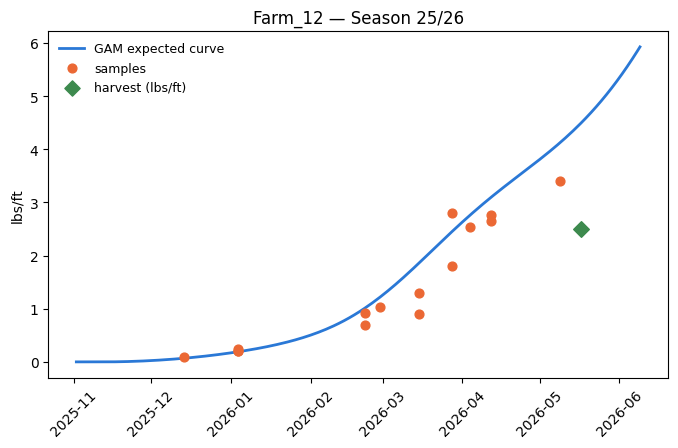

In [ ]:
plot_farm_season("Farm_12", "Season 25/26")     

### Expected curve: pick an outplanting date, integrate the rate forward

Start at yield 0 on the outplanting date (the known anchor) and step one day at a time: each day, ask
the GAM "at this yield, on this date, how fast is the kelp growing?" and take that step. The x-axis
is the calendar date, not age.

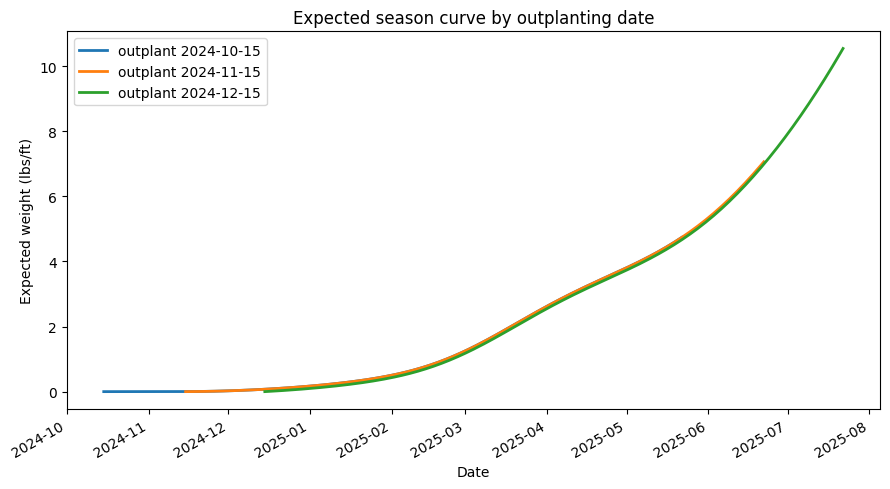

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
for d0 in ["2024-10-15", "2024-11-15", "2024-12-15"]:
    curve = project_curve_curr_dos(d0)
    ax.plot(curve.index, curve.values, lw=2, label=f"outplant {d0}")
ax.set_xlabel("Date"); ax.set_ylabel("Expected weight (lbs/ft)")
ax.legend(); ax.set_title("Expected season curve by outplanting date")
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

In [ ]:
grc["dos"].min()

np.int64(52)

/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_6919/1303812927.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grc["bin"] = pd.cut(grc["dos"], bins)


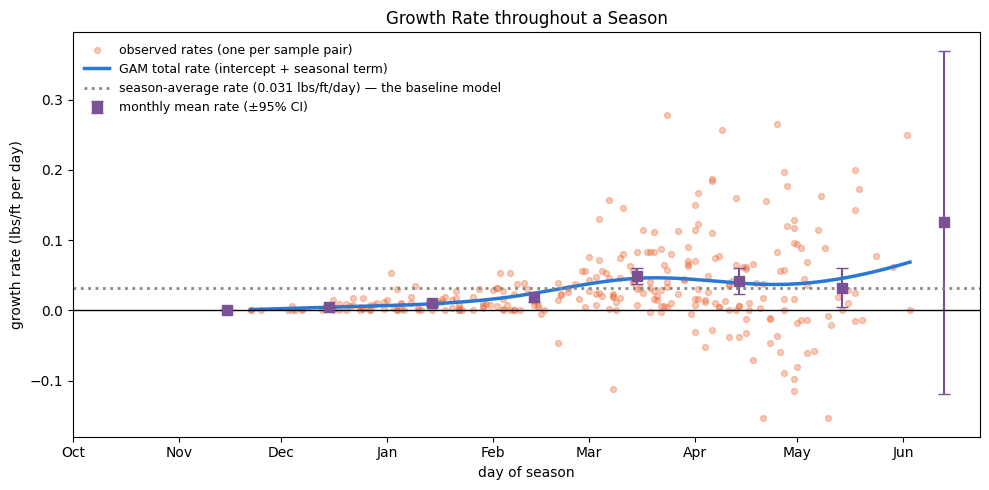

In [ ]:
# ---- total growth rate through the season: model vs observed ----
dos_grid = np.arange(grc["dos"].min(), grc["dos"].max() + 1)
rate_pred = gam_curr_dos.predict(dos_grid.reshape(-1, 1))          # intercept + f(dos): the TOTAL rate

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(grc["dos"], grc["rate"], s=18, alpha=0.35, color="#eb6834",
           label="observed rates (one per sample pair)")

# monthly binned means of the observed rates, with a simple error bar
bins = np.arange(30, 271, 30)
grc["bin"] = pd.cut(grc["dos"], bins)
bm = grc.groupby("bin", observed=True)["rate"].agg(["mean", "sem", "count"])
centers = [b.mid for b in bm.index]
ax.errorbar(centers, bm["mean"], yerr=1.96 * bm["sem"], fmt="s", color="#7a5195",
            ms=7, capsize=4, label="monthly mean rate (±95% CI)")

ax.plot(dos_grid, rate_pred, color="#2a78d6", lw=2.5, label="GAM total rate (intercept + seasonal term)")
ax.axhline(0, color="black", lw=1)
mean_rate = grc["rate"].mean()
ax.axhline(mean_rate, color="#898781", lw=2, ls=":",
           label=f"season-average rate ({mean_rate:.3f} lbs/ft/day) — the baseline model")
ax.set_ylabel("growth rate (lbs/ft per day)")
ax.set_xlabel("day of season")

# month names on the axis instead of raw dos numbers
month_starts = pd.date_range("2024-10-01", "2025-06-01", freq="MS")
ax.set_xticks([(d - pd.Timestamp("2024-10-01")).days for d in month_starts])
ax.set_xticklabels([d.strftime("%b") for d in month_starts])
ax.legend(frameon=False, fontsize=9)
ax.set_title("Growth Rate throughout a Season")
plt.tight_layout(); plt.show()